<a href="https://colab.research.google.com/github/ValbertoFeitosa/facial-age-prediction/blob/main/Regress%C3%A3oAlgaritmos_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Descrição do Dataset**

MORPH consiste em:

    Imagens divididas em Train, Validação e Teste (80-10-10)
    Rótulos de idade e gênero fornecidos em arquivos CSV no índice
    As imagens são cortadas e alinhadas usando as bibliotecas DLIB e OpenCV em Python

Link: MORPH Dataset no Kaggle - https://www.kaggle.com/datasets/chiragsaipanuganti/morph

Número de imagens por conjunto:

    Train: 40.012
    Test: 5.002
    Validação: 5.001

Arquivos CSV do índice:

O dataset contém três arquivos CSV (Train, Test, Validação) com as seguintes colunas:

    age (idade)
    gender (gênero)
    filename (nome do arquivo)
    filepath (caminho do arquivo)

## **O Problema**

O objetivo é treinar algoritmos de Machine Learning (ML) utilizando uma base de dados de fotos para prever a idade do indivíduo com base em sua imagem.

### **Base Utilizada**

Devido a limitações computacionais, decidimos utilizar apenas a base de teste para treinar e avaliar nossos modelos, pois esse arquivo contém mais de 5.000 imagens, o que já representa um volume significativo de dados para a tarefa.

### **Referência Bibliográfica**

RICANEK, Kurt; TESSEMA, Tesfaye. MORPH-2. Kaggle, 2023. Disponível em: https://www.kaggle.com/ds/3576052. DOI: 10.34740/KAGGLE/DS/3576052. Acesso em: [28/01/2025].


### **Os autores**

Kurt Ricanek - Departamento de Ciência da Computação, Universidade da Carolina do Norte Wilmington, Wilmington, NC, EUA

Tesfaye Tessema - Departamento de Ciência da Computação da Universidade Addis Ababa, Addis Abeba, Etiópia


### **Metodologia**

**1- Verificação e Pré-processamento:**

Verificar se o arquivo Test.csv não contém dados faltantes ou discrepantes e, caso necessário, realizar as devidas correções.

**2- Representações das Imagens:**

Utilizaremos duas formas de representação das fotos para o treinamento do nosso algoritmo:

Sem redes neurais: Vetorização utilizando a função de embedding ensinada pelo professor.

Com rede neural pré-treinada: Representação vetorial gerada pela função getEmbedder, também ensinada em sala pelo professor.

No final, faremos uma comparação do desempenho dos modelos utilizando as diferentes representações.

**3- Modelos de Regressão:**

Como o problema envolve previsão de idade (regressão), utilizaremos os seguintes modelos:

Regressão Linear

Árvore de Decisão



**4- Métricas de Avaliação:**

Para avaliar o desempenho dos modelos, utilizaremos as seguintes métricas:

  MAE (Erro Médio Absoluto)

  MSE (Erro Quadrático Médio)

  RMSE (Root Mean Squared Error, ou Erro Quadrático Médio da Raiz)

  $R^2$ (Coeficiente de Determinação)

### Relação entre RMSE e MSE

O **Erro Quadrático Médio (MSE)** é definido como:

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

O **Raiz do Erro Quadrático Médio (RMSE)** é simplesmente a raiz quadrada do MSE:

$$
RMSE = \sqrt{MSE}
$$

Portanto, podemos expressar essa relação como:

$$
RMSE = MSE^{\frac{1}{2}}
$$

Ou de forma equivalente:

$$
RMSE = \sqrt{MSE}
$$



**5- Gráficos de Análise:**

Valor previsto vs. Valor real: Para verificar se os dados seguem uma distribuição próxima a uma reta, indicando um bom ajuste do modelo.



### **Montado o drive**

In [ ]:
# Importa o módulo drive da biblioteca google.colab, que permite acessar o Google Drive diretamente no ambiente do Google Colab.
from google.colab import drive

# Monta o Google Drive no diretório '/content/drive', criando um ponto de montagem local no sistema de arquivos do Colab.
# Isso permite que o usuário acesse arquivos do seu Google Drive como se estivessem em um diretório local.
drive.mount('/content/drive')

Mounted at /content/drive


### **1- Verificação e Pré-processamento:**

In [ ]:
# Importação de bibliotecas para manipulação de dados
import os  # Para manipulação de diretórios e arquivos
import numpy as np  # Para operações numéricas
import pandas as pd  # Para manipulação de dados

# Importação de bibliotecas para visualização de dados
import matplotlib.pyplot as plt  # Para gráficos
import seaborn as sns  # Para gráficos estatísticos

# Importação de bibliotecas para manipulação de imagens
from PIL import Image  # Para carregar e processar imagens
from tensorflow.keras.preprocessing import image  # Para pré-processamento de imagens no TensorFlow

# Importação de bibliotecas para pré-processamento de dados
from sklearn import preprocessing  # Para normalização e padronização de dados

# Importação de bibliotecas do scikit-learn para modelagem
from sklearn.model_selection import train_test_split  # Para dividir os dados em treino e teste
from sklearn.linear_model import LinearRegression  # Modelo de Regressão Linear
from sklearn.tree import DecisionTreeRegressor  # Modelo de Árvore de Decisão para regressão
from sklearn.ensemble import RandomForestClassifier  # Modelo de Random Forest para classificação

# Importação de métricas de avaliação
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Métricas para avaliação de regressão


### **Carregamento dos Dados**

**Observação:**
O arquivo Test.csv apresentava problemas na coluna age (idade). Durante a verificação, analisamos algumas fotos e identificamos inconsistências nos valores de idade. Por exemplo, algumas imagens apresentavam idades como 2 anos, mas a foto claramente mostrava uma pessoa mais velha.

Após investigar, percebemos que o nome dos arquivos de imagem seguia um padrão no formato:

00189_01M18.JPG

    Os três últimos caracteres antes da extensão (.JPG) indicam a idade correta.
    O formato segue a estrutura M ou F, representando Masculino ou Feminino, seguido da idade.
    Assim, no exemplo 00189_01M18.JPG, a idade correta da pessoa é 18 anos.

Para corrigir essa inconsistência, substituímos os valores da coluna age pelos valores extraídos do nome do arquivo. Esse ajuste foi realizado manualmente no Excel antes do processamento dos dados.

Utilizamos a função: **EXT.TEXTO(D2;LOCALIZAR(".";D2)-2;2)**

In [ ]:
# Caminho do arquivo CSV - com a idade corrigida
train_csv_path = '/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_2/Pacote Estatistico/TrabalhoN2/Index/Test3.xlsx'


# Carregar o arquivo CSV
#train_data = pd.read_csv(train_csv_path)
train_data = pd.read_excel(train_csv_path)

# Verificar os dados
print(train_data.head())


   age  gender         filename  \
0   18       1  00189_01M18.JPG   
1   19       1  00242_06M19.JPG   
2   22       1  00257_01M22.JPG   
3   20       1  00425_03M20.JPG   
4   37       0   00457_1F37.JPG   

                                            filepath  
0  /kaggle/input/morph/Dataset/Images/Test/00189_...  
1  /kaggle/input/morph/Dataset/Images/Test/00242_...  
2  /kaggle/input/morph/Dataset/Images/Test/00257_...  
3  /kaggle/input/morph/Dataset/Images/Test/00425_...  
4  /kaggle/input/morph/Dataset/Images/Test/00457_...  


In [ ]:
# Atualizar os caminhos com base na localização dos arquivos
base_path = '/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_2/Pacote Estatistico/TrabalhoN2/Imagens/Test'

train_data['filepath'] = train_data['filepath'].str.replace('/kaggle/input/morph/Dataset/Images/Test', base_path)

# Verificar os primeiros 5 caminhos
print(train_data['filepath'].head())


0    /content/drive/MyDrive/CienciaDeDadosAtuariais...
1    /content/drive/MyDrive/CienciaDeDadosAtuariais...
2    /content/drive/MyDrive/CienciaDeDadosAtuariais...
3    /content/drive/MyDrive/CienciaDeDadosAtuariais...
4    /content/drive/MyDrive/CienciaDeDadosAtuariais...
Name: filepath, dtype: object


In [ ]:
train_data

,age,gender,filename,filepath
0,18,1,00189_01M18.JPG,/content/drive/MyDrive/CienciaDeDadosAtuariais...
1,19,1,00242_06M19.JPG,/content/drive/MyDrive/CienciaDeDadosAtuariais...
2,22,1,00257_01M22.JPG,/content/drive/MyDrive/CienciaDeDadosAtuariais...
3,20,1,00425_03M20.JPG,/content/drive/MyDrive/CienciaDeDadosAtuariais...
4,37,0,00457_1F37.JPG,/content/drive/MyDrive/CienciaDeDadosAtuariais...
...,...,...,...,...
4997,59,1,9893_38M59.JPG,/content/drive/MyDrive/CienciaDeDadosAtuariais...
4998,17,1,99023_02M17.JPG,/content/drive/MyDrive/CienciaDeDadosAtuariais...
4999,19,1,99023_05M19.JPG,/content/drive/MyDrive/CienciaDeDadosAtuariais...
5000,22,1,99267_05M22.JPG,/content/drive/MyDrive/CienciaDeDadosAtuariais...


In [ ]:
print(train_data['filepath'].iloc[0])  # Mostra o caminho da primeira imagem



/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_2/Pacote Estatistico/TrabalhoN2/Imagens/Test/00189_01M18.JPG


In [ ]:
#train_data['filepath'] = train_data['filepath'].str.replace('Imagens/', 'Imagens/Test/')


Formato da imagem: JPEG
Tamanho (Largura x Altura): (180, 180)
Modo de cor: RGB


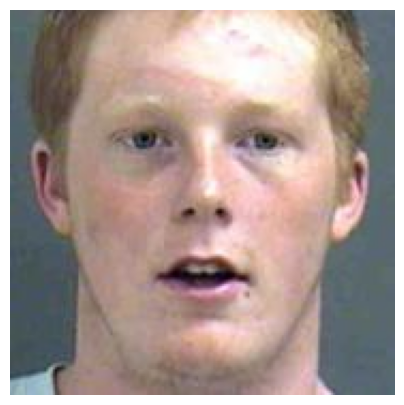

In [ ]:
# Selecionar o caminho do arquivo da primeira imagem no dataset de treino
img_path = train_data['filepath'].iloc[0]  # Obtém o caminho da primeira imagem

# Abrir a imagem usando a biblioteca PIL (Pillow)
img = Image.open(img_path)

# Exibir informações básicas da imagem
print(f"Formato da imagem: {img.format}")  # Exemplo: JPEG, PNG, BMP, etc.
print(f"Tamanho (Largura x Altura): {img.size}")  # Exemplo: (1280, 720)
print(f"Modo de cor: {img.mode}")  # Exemplo: RGB, RGBA, L (grayscale), etc.

# Exibir a imagem no visualizador do sistema (opcional)
# img.show()  # Essa linha está comentada para evitar a abertura externa da imagem

# Exibir a imagem dentro do notebook usando Matplotlib
plt.figure(figsize=(5, 5))  # Ajusta o tamanho da exibição
plt.imshow(img)  # Exibe a imagem
plt.axis('off')  # Remove os eixos para melhor visualização
plt.show()  # Renderiza a imagem no notebook



## **2- Representações das Imagens**

### **Vetorização utilizando a função de embedding ensinada pelo professor- Sem redes neurais**

In [ ]:
# Configurações para pré-processamento das imagens
largura = 128  # Definição da largura da imagem
altura = 128   # Definição da altura da imagem
modo_de_cor = "rgb"  # Define o modo de cor ("grayscale" para tons de cinza ou "rgb" para colorido)

# Função para converter a imagem em um vetor numérico (embedding)
def embedding(img_path, largura, altura, modo_de_cor):
    """
    Função para carregar e processar uma imagem, transformando-a em um vetor normalizado.

    Parâmetros:
    - img_path (str): Caminho da imagem.
    - largura (int): Largura desejada da imagem.
    - altura (int): Altura desejada da imagem.
    - modo_de_cor (str): "grayscale" para tons de cinza, "rgb" para colorido, "rgba" para imagens com canal alfa.

    Retorna:
    - Um vetor unidimensional representando a imagem, normalizado entre [0,1].
    """

    # Carregar a imagem e redimensionar para o tamanho especificado
    img = image.load_img(img_path, target_size=(largura, altura), color_mode=modo_de_cor)

    # Converter a imagem para um array NumPy
    embed = image.img_to_array(img)

    # Definir o tamanho da entrada de acordo com o modo de cor
    shape_entrada = largura * altura * 1  # Padrão para grayscale (tons de cinza)
    if modo_de_cor == 'rgb':
        shape_entrada = largura * altura * 3  # 3 canais para imagens coloridas
    elif modo_de_cor == 'rgba':
        shape_entrada = largura * altura * 4  # 4 canais para imagens com transparência

    # Retorna o vetor sem normalização
    return embed.reshape(shape_entrada)

In [ ]:
# Definir a variável alvo (idades)
target = train_data['age'].values  # Usa .values para obter um array NumPy diretamente

# Lista para armazenar as features extraídas das imagens
array_features = []

# Aplicar a função de embedding em todas as imagens do dataset
for fp in train_data['filepath']:
    array_features.append(embedding(fp, largura, altura, modo_de_cor))

# Converter a lista para um array NumPy para facilitar o processamento
array_features = np.array(array_features)

# Normalizar os dados usando StandardScaler (média 0, desvio padrão 1)
scaler = preprocessing.StandardScaler()
array_features = scaler.fit_transform(array_features)

# Criar um DataFrame do Pandas com as features normalizadas
df_features = pd.DataFrame(array_features)

# Exibir as primeiras linhas do DataFrame para verificação
df_features.head()

In [ ]:
# Definir o caminho onde o arquivo será salvo no Drive
#caminho_arquivo = '/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_2/Pacote Estatistico/TrabalhoN2/dataset_processado.csv'  # Altere o nome do arquivo se necessário

# Salvar o DataFrame como CSV no Google Drive
#df_features.to_csv(caminho_arquivo, index=False)

#print(f"Arquivo salvo com sucesso em: {caminho_arquivo}")

Arquivo salvo com sucesso em: /content/drive/MyDrive/CienciaDeDadosAtuariais_2024_2/Pacote Estatistico/TrabalhoN2/dataset_processado.csv


In [ ]:
# Vizualizando o dataset df_features
Visualizacao=pd.read_csv('/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_2/Pacote Estatistico/TrabalhoN2/dataset_processado.csv')
Visualizacao

,0,1,2,3,4,5,6,7,8,9,...,49142,49143,49144,49145,49146,49147,49148,49149,49150,49151
0,-0.566286,-0.399011,-0.440533,-0.619218,-0.476004,-0.474901,-0.654906,-0.511152,-0.504743,-0.651962,...,0.015529,-0.269468,-0.041422,0.013354,-0.250647,0.006032,0.053521,-0.189432,0.068476,0.115637
1,0.260669,0.324313,0.292629,0.202630,0.285525,0.223078,0.167621,0.250870,0.193236,0.167567,...,-0.419281,-0.570599,-0.524120,-0.388847,-0.552545,-0.508820,-0.349738,-0.513238,-0.470185,-0.310212
2,1.027482,1.004237,1.011691,0.931439,0.912666,0.921056,0.942694,0.921449,0.935768,1.003165,...,-0.595275,-0.510373,-0.493310,-0.533227,-0.612925,-0.580899,-0.649598,-0.867401,-0.843103,-0.912634
3,-1.904449,-1.917992,-1.920955,-2.014810,-2.028925,-2.030812,-2.078510,-2.096157,-2.093761,-2.130328,...,-0.812680,-1.092561,-1.088980,-1.110746,-1.075836,-1.075157,-1.114897,-1.009067,-1.008845,-1.047659
4,0.350882,0.382179,0.306728,0.357696,0.375116,0.339408,0.357435,0.372793,0.341743,0.247913,...,-0.833385,-0.570599,-0.657633,-0.687919,-0.602861,-0.694167,-0.721978,-0.958472,-1.039921,-1.078819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4997,-0.897068,-0.919804,-0.990404,-0.975869,-0.998621,-1.042008,-1.018716,-1.044567,-1.083918,-1.037623,...,1.495952,1.467060,1.529917,1.498403,1.490301,1.550587,1.521799,1.540908,1.601586,1.569758
4998,-1.904449,-1.917992,-1.920955,-2.014810,-2.028925,-2.030812,-2.078510,-2.096157,-2.093761,-2.130328,...,-1.143964,-1.092561,-1.088980,-1.131371,-1.075836,-1.075157,-1.114897,-1.039423,-1.039921,-1.078819
4999,-1.904449,-1.917992,-1.920955,-2.014810,-2.028925,-2.030812,-2.078510,-2.096157,-2.093761,-2.130328,...,-1.143964,-1.092561,-1.088980,-1.131371,-1.075836,-1.075157,-1.114897,-1.039423,-1.039921,-1.078819
5000,1.162802,1.293567,1.406470,1.241571,1.345692,1.473623,1.290687,1.393902,1.529793,1.195995,...,0.823033,0.643966,0.780193,0.817755,0.785872,0.922468,0.942760,-1.039423,-1.029562,-1.026886


### **3- Modelos de Regressão:**

Como o problema envolve previsão de idade (regressão), utilizaremos os seguintes modelos:

Regressão Linear

Árvore de Decisão


In [ ]:
def getModel(model_type="linear"):
    """
    Retorna um modelo de aprendizado de máquina para prever idade.

    Parâmetros:
        model_type (str): Tipo do modelo desejado. Opções:
            - "linear"  : Regressão Linear
            - "tree"    : Árvore de Decisão
            - "forest"  : Random Forest

    Retorna:
        Um modelo sklearn pronto para treino.
    """
    if model_type == "linear":
        return LinearRegression()
    elif model_type == "tree":
        return DecisionTreeRegressor(max_depth=5)
    elif model_type == "forest":
        return RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
    else:
        raise ValueError("Modelo não reconhecido. Escolha entre 'linear', 'tree' ou 'forest'.")


In [ ]:
# Divisão dos dados em conjunto de treino e teste

# Parâmetros:
# - df_features.values -> Matriz de features (dados processados das imagens)
# - target -> Vetor com os rótulos (idades dos indivíduos)
# - test_size=0.2 -> Define que 20% dos dados serão usados para teste e 80% para treino
# - random_state=42 -> Garante que a divisão dos dados seja sempre a mesma, garantindo reprodutibilidade

X_treino, X_teste, y_treino, y_teste = train_test_split(df_features.values, target, test_size=0.2, random_state=42)

# Após a divisão, temos:
# - X_treino: Features usadas para treinar o modelo (80% dos dados)
# - X_teste: Features usadas para testar o modelo (20% dos dados)
# - y_treino: Rótulos correspondentes ao conjunto de treino
# - y_teste: Rótulos correspondentes ao conjunto de teste

# Garantia de reprodutibilidade:
# O parâmetro `random_state=42` assegura que a divisão seja sempre a mesma a cada execução,
# facilitando comparações entre execuções do modelo e garantindo resultados consistentes.


### **4- Treinamento e Métricas de Avaliação**

Para avaliar o desempenho dos modelos, utilizaremos as seguintes métricas:

MAE (Erro Médio Absoluto)

MSE (Erro Quadrático Médio)

RMSE (Root Mean Squared Error, ou Erro Quadrático Médio da Raiz)

R2 (Coeficiente de Determinação)



In [ ]:
# Criar um DataFrame para armazenar os valores reais e previstos temporariamente
df_resultados = pd.DataFrame(columns=["Modelo", "Valor Real", "Valor Previsto"])

# Loop para treinar e avaliar diferentes modelos de regressão
for model_type in ["linear", "tree"]: # "forest"]:

    # Obter o modelo correspondente (Regressão Linear, Árvore de Decisão ou Random Forest)
    model = getModel(model_type)

    # Treinar o modelo com os dados de treino
    model.fit(X_treino, y_treino)

    # Fazer previsões no conjunto de teste
    y_pred = model.predict(X_teste)

    # Calcular métricas de erro para avaliação do modelo
    mae = mean_absolute_error(y_teste, y_pred)
    mse = mean_squared_error(y_teste, y_pred)
    r2 = r2_score(y_teste, y_pred)

    # Exibir os resultados para cada modelo
    print(f"\nModelo: {model_type}")
    print(f"MAE (Erro Médio Absoluto): {mae:.2f}")
    print(f"MSE (Erro Quadrático Médio): {mse:.2f}")
    print(f"R² (Coeficiente de Determinação): {r2:.4f}")

    # Criar um DataFrame temporário para armazenar os valores reais e previstos
    df_temp = pd.DataFrame({"Modelo": model_type, "Valor Real": y_teste, "Valor Previsto": y_pred})

    # Concatenar os resultados com o DataFrame principal
    df_resultados = pd.concat([df_resultados, df_temp], ignore_index=True)

# Exibir as primeiras linhas do DataFrame com os valores reais e previstos
df_resultados.head()



Modelo: linear
MAE (Erro Médio Absoluto): 5.73
MSE (Erro Quadrático Médio): 52.31
R² (Coeficiente de Determinação): 0.5396


<ipython-input-24-504887019c95>:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_resultados = pd.concat([df_resultados, df_temp], ignore_index=True)



Modelo: tree
MAE (Erro Médio Absoluto): 7.88
MSE (Erro Quadrático Médio): 95.28
R² (Coeficiente de Determinação): 0.1615


,Modelo,Valor Real,Valor Previsto
0,linear,39,35.009041
1,linear,26,36.075314
2,linear,23,27.794708
3,linear,47,53.046074
4,linear,40,33.750717


## **Modelo: Linear**

MAE (Erro Médio Absoluto): 5.73

MSE (Erro Quadrático Médio): 52.31

RMSE (Raiz do Erro Quadrático Médio): 7.23

R² (Coeficiente de Determinação): 0.5396


## **Modelo: Tree**

MAE (Erro Médio Absoluto): 7.88

MSE (Erro Quadrático Médio): 95.28

RMSE (Raiz do Erro Quadrático Médio): 9.76

R² (Coeficiente de Determinação): 0.1615


### **5- Gráficos de Análise:**

Valor previsto vs. Valor real: Para verificar se os dados seguem uma distribuição próxima a uma reta, indicando um bom ajuste do modelo.

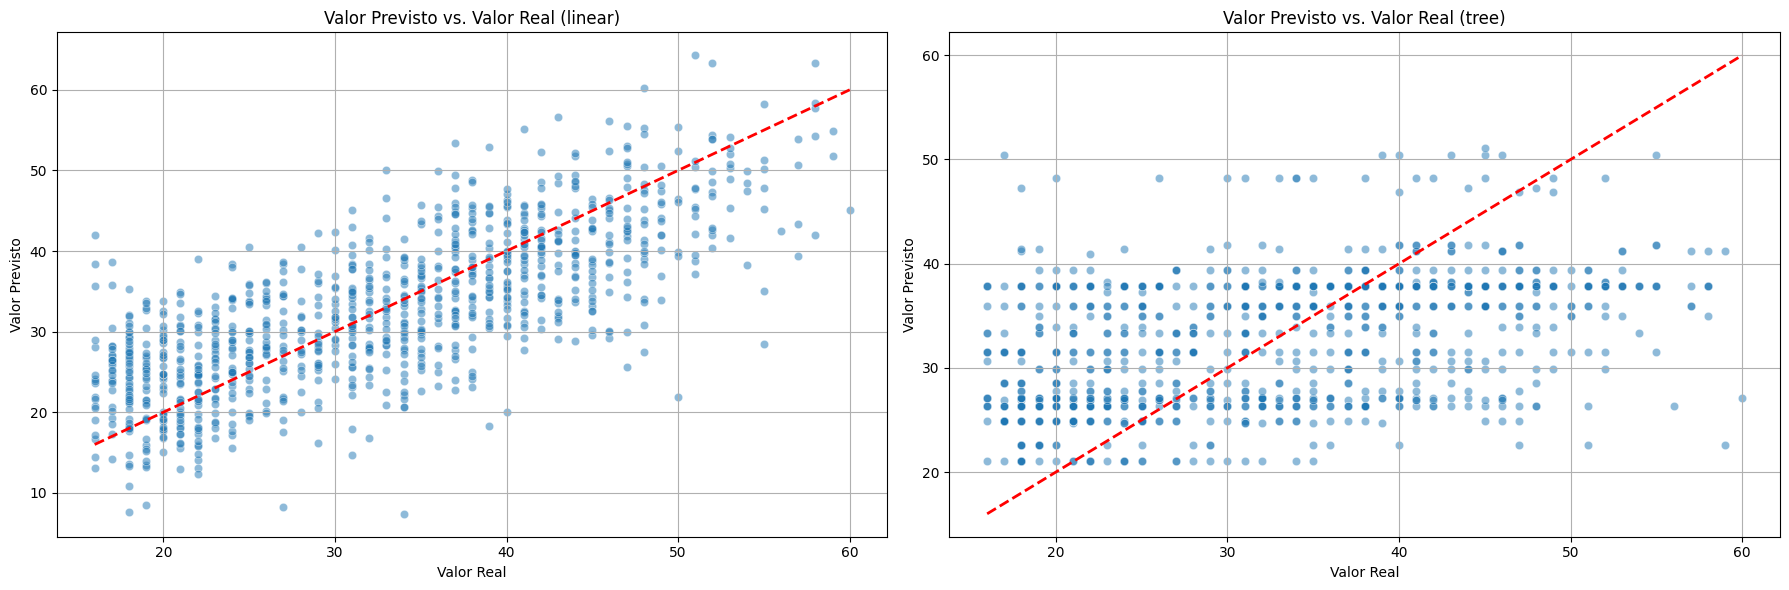

In [ ]:
# Lista dos modelos disponíveis
modelos = ["linear", "tree"] #"forest"]

# Criar uma figura com três subgráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 6))  # 1 linha, 2 colunas

# Loop para criar um gráfico para cada modelo
for i, modelo in enumerate(modelos):
    # Filtrar os dados do modelo atual
    df_plot = df_resultados[df_resultados["Modelo"] == modelo]

    # Criar o gráfico de dispersão
    sns.scatterplot(ax=axes[i], x=df_plot["Valor Real"], y=df_plot["Valor Previsto"], alpha=0.5)

    # Adicionar uma linha de referência y=x para avaliar o ajuste do modelo
    axes[i].plot([df_plot["Valor Real"].min(), df_plot["Valor Real"].max()],
                 [df_plot["Valor Real"].min(), df_plot["Valor Real"].max()],
                 color="red", linestyle="--", linewidth=2)

    # Configuração do gráfico
    axes[i].set_title(f"Valor Previsto vs. Valor Real ({modelo})")
    axes[i].set_xlabel("Valor Real")
    axes[i].set_ylabel("Valor Previsto")
    axes[i].grid()

# Ajustar espaçamento entre os gráficos
plt.tight_layout()

# Mostrar os gráficos
plt.show()


Observações do Professor

RMse

Df_features sem “head”

Max Def 2 ou 3 ao invés de 5 no decision tree

Usar b2 ou B1 ao invés de b3 na rede neural


### **2- Representações das Imagens**


**Com rede neural pré-treinada: Representação vetorial gerada pela função getEmbedder, também ensinada em sala pelo professor**


In [ ]:
# import tensorflow as tf
# import os

# # DESCOMENTAR PARA FORÇAR A RODAR EM CPU
# # os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# # Certifique-se de que nenhuma operação TensorFlow foi feita antes dessa configuração
# physical_devices = tf.config.experimental.list_physical_devices('GPU')

# if len(physical_devices) > 0:
#     try:
#         tf.config.experimental.set_memory_growth(physical_devices[0], True)  # Necessário para a CNN
#         print("Configuração de crescimento de memória ativada na GPU.")
#     except RuntimeError as e:
#         print("Erro ao configurar a GPU:", e)

# print('tf version: ', tf.__version__)
# print('num gpus: ', len(physical_devices))


In [ ]:
# Configurações para pré-processamento das imagens
largura = 300  # Definição da largura da imagem
altura = 300   # Definição da altura da imagem
modo_de_cor = "rgb"  # Define o modo de cor ("grayscale" para tons de cinza ou "rgb" para colorido)


In [ ]:
# Importação de modelos pré-treinados para extração de características (embeddings)
from tensorflow.keras.applications import EfficientNetB0, InceptionV3
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.efficientnet import EfficientNetB0, EfficientNetB1, EfficientNetB2, EfficientNetB3, EfficientNetB4, EfficientNetB5, EfficientNetB6, EfficientNetB7
from tensorflow.keras.applications.efficientnet import preprocess_input

# Função para obter um modelo pretreinado como extrator de características (embedding)
def getEmbedder():
    """
    Retorna um modelo pré-treinado para extração de características (embeddings) de imagens.

    O modelo escolhido é o EfficientNetB0 com pesos pré-treinados no ImageNet.
    Outras versões do EfficientNet (B1, B2, B3, B4, B5, B7) ou InceptionV3 podem ser usadas,
    bastando descomentar a linha correspondente.

    Retorna:
    - Um modelo Keras pré-treinado sem a camada de classificação final (include_top=False).
    """
    # return EfficientNetB0(weights='imagenet', include_top=False)  # Modelo padrão
    # return EfficientNetB1(weights='imagenet', include_top=False)  # Nova opção adicionada
    return EfficientNetB2(weights='imagenet', include_top=False)
    # return EfficientNetB3(weights='imagenet', include_top=False)
    # return EfficientNetB3(weights='imagenet', include_top=False, input_shape=(300, 300, 3))
    # return EfficientNetB4(weights='imagenet', include_top=False)
    # return EfficientNetB5(weights='imagenet', include_top=False)
    # return EfficientNetB7(weights='imagenet', include_top=False)
    # return InceptionV3(weights='imagenet', include_top=False)

# Função para extrair embeddings de uma imagem usando o modelo carregado
def embedding(embedder, img_path):
    """
    Processa uma imagem e extrai seus embeddings usando um modelo pré-treinado.

    Parâmetros:
    - embedder: O modelo carregado para extração de embeddings.
    - img_path (str): Caminho do arquivo da imagem a ser processada.

    Retorna:
    - Um vetor de características extraído da imagem.
    """
    # Carregar e redimensionar a imagem
    img = image.load_img(img_path, target_size=(largura, altura), color_mode=modo_de_cor)

    # Converter a imagem para um array NumPy
    embed = image.img_to_array(img)

    # Expandir a dimensão para compatibilidade com o modelo (formato esperado pelo Keras)
    embed = np.expand_dims(embed, axis=0)

    # Aplicar pré-processamento adequado ao modelo (se necessário)
    embed = preprocess_input(embed)  # Pode ser ativado se o modelo exigir normalização

    # Obter os embeddings da imagem (características extraídas)
    features = embedder.predict(embed, verbose=0)

    # Retornar a primeira característica extraída (primeira posição do tensor)
    return features.flatten() #features[0][0][0]

# Inicializar o modelo para extração de embeddings
embedder = getEmbedder()


In [ ]:
import tensorflow as tf
import os

# DESCOMENTAR PARA FORÇAR A RODAR EM CPU
# os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# Certifique-se de que nenhuma operação TensorFlow foi feita antes dessa configuração
physical_devices = tf.config.experimental.list_physical_devices('GPU')

if len(physical_devices) > 0:
    try:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)  # Necessário para a CNN
        print("Configuração de crescimento de memória ativada na GPU.")
    except RuntimeError as e:
        print("Erro ao configurar a GPU:", e)

print('tf version: ', tf.__version__)
print('num gpus: ', len(physical_devices))

Erro ao configurar a GPU: Physical devices cannot be modified after being initialized
tf version:  2.18.0
num gpus:  1


In [ ]:
# Definir a variável alvo (idades)
target = train_data['age'].values
# Usa .values para converter a coluna 'age' em um array NumPy diretamente.

# Criar uma lista para armazenar as características (features) extraídas das imagens
array_features = []

# Loop para processar todas as imagens do dataset e extrair suas features
for fp in train_data['filepath']:
    array_features.append(embedding(embedder, fp))  # Processa cada imagem usando a função de embedding

# Normalizar as features usando StandardScaler (para média 0 e desvio padrão 1)
scaler = preprocessing.StandardScaler()
array_features = scaler.fit_transform(array_features)

# Converter as features extraídas para um DataFrame Pandas
df_features = pd.DataFrame(array_features)

# Exibir as primeiras linhas do DataFrame para verificar os dados processados
df_features.head()

# tempo 6 minutos para EfficientNetB2 , outros foram mais de uma hora

,0,1,2,3,4,5,6,7,8,9,...,114038,114039,114040,114041,114042,114043,114044,114045,114046,114047
0,-0.015836,3.239397,-0.562754,-0.036165,-0.561439,-1.041089,0.873299,4.626634,-0.162501,-0.169579,...,-0.478320,0.110886,2.384195,0.253501,-0.474527,-0.517673,-0.241491,-0.035284,-0.326385,-0.415262
1,-0.288135,-0.408496,-0.561462,-0.166293,-0.173593,-1.125821,-0.721478,0.286090,-0.177370,0.043586,...,-0.063359,0.847149,-1.250769,0.491106,-0.451629,0.296724,-0.349567,-0.434406,-0.721938,-0.288858
2,-0.631466,-0.223910,-0.683581,-0.140995,-0.636223,-1.167065,1.322909,-0.520528,-0.418436,0.161372,...,-0.531606,0.247235,-0.000333,0.994192,-0.537765,-0.207830,-0.803592,0.454483,-0.842243,-0.324081
3,24.532835,0.865874,2.806870,-0.275980,3.908338,-1.089914,1.194600,0.172364,0.111813,1.055148,...,-0.526610,1.098777,0.489295,-0.785053,-0.497926,-0.510459,-0.370571,-0.347083,-0.449114,-0.403596
4,0.595012,6.580293,0.573385,-0.006656,-0.480690,-1.107463,0.372622,-0.520405,-0.356869,-0.600430,...,-0.072675,-0.169162,1.776309,3.928345,0.295666,3.154940,-0.213830,-0.526469,3.966196,0.040163


In [ ]:
# Definir o caminho onde o arquivo será salvo no Drive
# caminho_arquivo = '/content/drive/MyDrive/CienciaDeDadosAtuariais_2024_2/Pacote Estatistico/TrabalhoN2/dataset_B2.csv'  # Altere o nome do arquivo se necessário

# Salvar o DataFrame como CSV no Google Drive
# df_features.to_csv(caminho_arquivo, index=False)

# print(f"Arquivo salvo com sucesso em: {caminho_arquivo}")

Arquivo salvo com sucesso em: /content/drive/MyDrive/CienciaDeDadosAtuariais_2024_2/Pacote Estatistico/TrabalhoN2/dataset_B2.csv


### **3- Modelos de Regressão:**

Como o problema envolve previsão de idade (regressão), utilizaremos os seguintes modelos:

Regressão Linear

Árvore de Decisão



In [ ]:
def getModel(model_type="linear"):
    """
    Retorna um modelo de aprendizado de máquina para prever idade.

    Parâmetros:
        model_type (str): Tipo do modelo desejado. Opções:
            - "linear"  : Regressão Linear
            - "tree"    : Árvore de Decisão
            - "forest"  : Random Forest

    Retorna:
        Um modelo sklearn pronto para treino.
    """
    if model_type == "linear":
        return LinearRegression()
    elif model_type == "tree":
        return DecisionTreeRegressor(max_depth=3)  # Max Def 2 ou 3 ao invés de 5 no decision tree
    elif model_type == "forest":
        return RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
    else:
        raise ValueError("Modelo não reconhecido. Escolha entre 'linear', 'tree' ou 'forest'.")


In [ ]:
# Divisão dos dados em conjunto de treino e teste

# Parâmetros:
# - df_features.values -> Matriz de features (dados processados das imagens)
# - target -> Vetor com os rótulos (idades dos indivíduos)
# - test_size=0.2 -> Define que 20% dos dados serão usados para teste e 80% para treino
# - random_state=42 -> Garante que a divisão dos dados seja sempre a mesma, garantindo reprodutibilidade

X_treino, X_teste, y_treino, y_teste = train_test_split(df_features.values, target, test_size=0.2, random_state=42)

# Após a divisão, temos:
# - X_treino: Features usadas para treinar o modelo (80% dos dados)
# - X_teste: Features usadas para testar o modelo (20% dos dados)
# - y_treino: Rótulos correspondentes ao conjunto de treino
# - y_teste: Rótulos correspondentes ao conjunto de teste

# Garantia de reprodutibilidade:
# O parâmetro `random_state=42` assegura que a divisão seja sempre a mesma a cada execução,
# facilitando comparações entre execuções do modelo e garantindo resultados consistentes.


### **4- Treinamento e Métricas de Avaliação**

Para avaliar o desempenho dos modelos, utilizaremos as seguintes métricas:

MAE (Erro Médio Absoluto)

MSE (Erro Quadrático Médio)

RMSE (Root Mean Squared Error, ou Erro Quadrático Médio da Raiz)

R2 (Coeficiente de Determinação)

In [ ]:
# Criar um DataFrame para armazenar os valores reais e previstos temporariamente
df_resultados = pd.DataFrame(columns=["Modelo", "Valor Real", "Valor Previsto"])

# Loop para treinar e avaliar diferentes modelos de regressão
for model_type in ["linear", "tree"]: # "forest"]:

    # Obter o modelo correspondente (Regressão Linear, Árvore de Decisão ou Random Forest)
    model = getModel(model_type)

    # Treinar o modelo com os dados de treino
    model.fit(X_treino, y_treino)

    # Fazer previsões no conjunto de teste
    y_pred = model.predict(X_teste)

    # Calcular métricas de erro para avaliação do modelo
    mae = mean_absolute_error(y_teste, y_pred)
    mse = mean_squared_error(y_teste, y_pred)
    r2 = r2_score(y_teste, y_pred)

    # Exibir os resultados para cada modelo
    print(f"\nModelo: {model_type}")
    print(f"MAE (Erro Médio Absoluto): {mae:.2f}")
    print(f"MSE (Erro Quadrático Médio): {mse:.2f}")
    print(f"R² (Coeficiente de Determinação): {r2:.4f}")

    # Criar um DataFrame temporário para armazenar os valores reais e previstos
    df_temp = pd.DataFrame({"Modelo": model_type, "Valor Real": y_teste, "Valor Previsto": y_pred})

    # Concatenar os resultados com o DataFrame principal
    df_resultados = pd.concat([df_resultados, df_temp], ignore_index=True)

# Exibir as primeiras linhas do DataFrame com os valores reais e previstos
df_resultados.head()


Modelo: linear
MAE (Erro Médio Absoluto): 4.35
MSE (Erro Quadrático Médio): 29.97
R² (Coeficiente de Determinação): 0.7363


<ipython-input-23-89edaa8323dd>:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_resultados = pd.concat([df_resultados, df_temp], ignore_index=True)



Modelo: tree
MAE (Erro Médio Absoluto): 6.79
MSE (Erro Quadrático Médio): 71.95
R² (Coeficiente de Determinação): 0.3668


,Modelo,Valor Real,Valor Previsto
0,linear,39,42.695404
1,linear,26,31.554164
2,linear,23,29.275547
3,linear,47,45.944813
4,linear,40,40.186950


## **Resultados com EfficientNetB1**

**Modelo: Linear**

MAE (Erro Médio Absoluto): 4.12

MSE (Erro Quadrático Médio): 27.23

RMSE (Raiz do Erro Quadrático Médio): 5.22

R² (Coeficiente de Determinação): 0.7603



**Modelo: Tree - max_depth=2**

MAE (Erro Médio Absoluto): 6.97

MSE (Erro Quadrático Médio): 72.91

RMSE (Raiz do Erro Quadrático Médio): 8.54

R² (Coeficiente de Determinação): 0.3584



## **Resultados com EfficientNetB2**

**Modelo: Linear**

MAE (Erro Médio Absoluto): 4.35

MSE (Erro Quadrático Médio): 29.97

RMSE (Raiz do Erro Quadrático Médio): 5.47

R² (Coeficiente de Determinação): 0.7363



**Modelo: Tree - max_depth=3**

MAE (Erro Médio Absoluto): 6.79

MSE (Erro Quadrático Médio): 71.95

RMSE (Raiz do Erro Quadrático Médio): 8.49

R² (Coeficiente de Determinação): 0.3668


## **Resultados com EfficientNetB3**

**Modelo: Linear**

MAE (Erro Médio Absoluto): 4.29

MSE (Erro Quadrático Médio): 29.22

RMSE (Raiz do Erro Quadrático Médio): 5.41

R² (Coeficiente de Determinação): 0.7428

**Modelo: Tree - max_depth=5**

MAE (Erro Médio Absoluto): 6.87

MSE (Erro Quadrático Médio): 75.03

RMSE (Raiz do Erro Quadrático Médio): 8.66

R² (Coeficiente de Determinação): 0.3396


### **5- Gráficos de Análise:**

Valor previsto vs. Valor real: Para verificar se os dados seguem uma distribuição próxima a uma reta, indicando um bom ajuste do modelo.

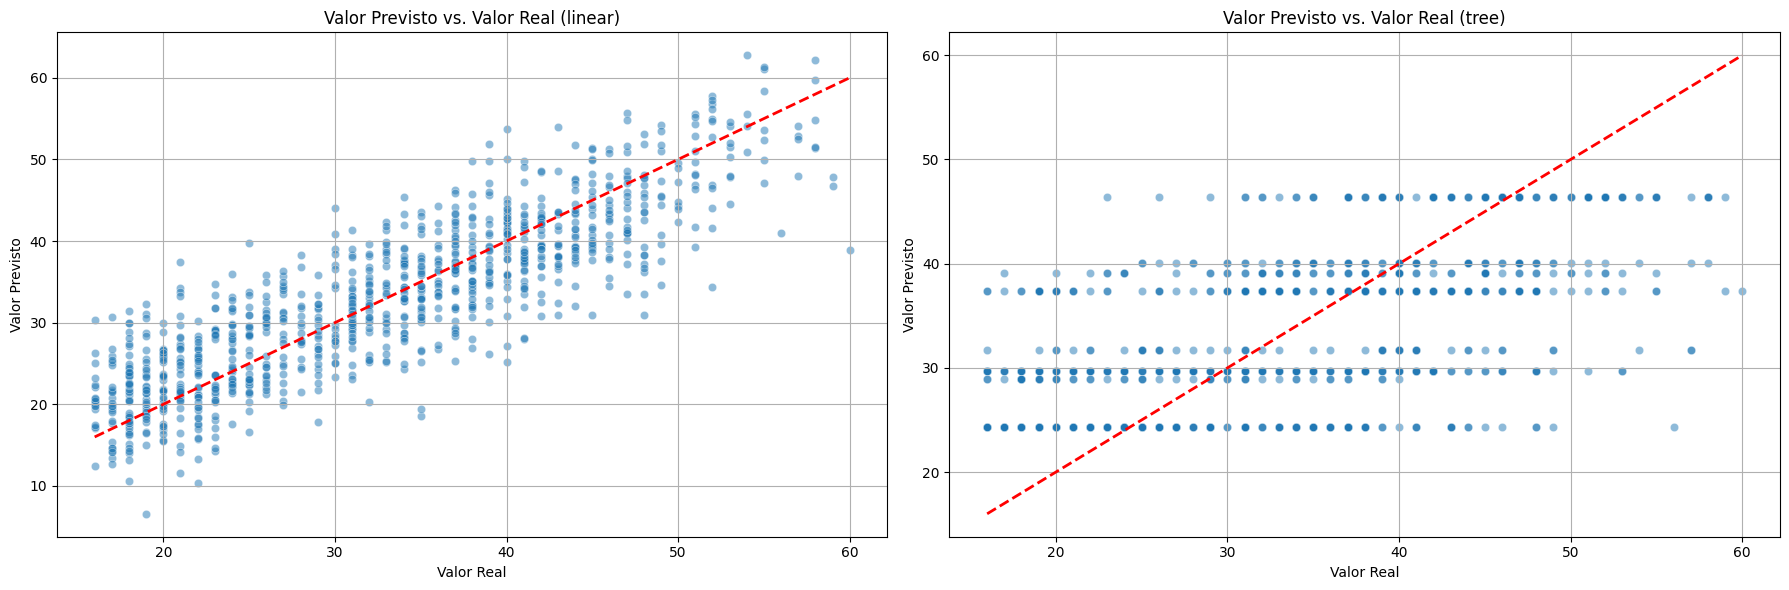

In [ ]:
# Lista dos modelos disponíveis
modelos = ["linear", "tree"] #"forest"]

# Criar uma figura com três subgráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 6))  # 1 linha, 2 colunas

# Loop para criar um gráfico para cada modelo
for i, modelo in enumerate(modelos):
    # Filtrar os dados do modelo atual
    df_plot = df_resultados[df_resultados["Modelo"] == modelo]

    # Criar o gráfico de dispersão
    sns.scatterplot(ax=axes[i], x=df_plot["Valor Real"], y=df_plot["Valor Previsto"], alpha=0.5)

    # Adicionar uma linha de referência y=x para avaliar o ajuste do modelo
    axes[i].plot([df_plot["Valor Real"].min(), df_plot["Valor Real"].max()],
                 [df_plot["Valor Real"].min(), df_plot["Valor Real"].max()],
                 color="red", linestyle="--", linewidth=2)

    # Configuração do gráfico
    axes[i].set_title(f"Valor Previsto vs. Valor Real ({modelo})")
    axes[i].set_xlabel("Valor Real")
    axes[i].set_ylabel("Valor Previsto")
    axes[i].grid()

# Ajustar espaçamento entre os gráficos
plt.tight_layout()

# Mostrar os gráficos
plt.show()


## **Gráfico do Valor Previsto vs Valor Real com EfficientNetB1 - Tree max_depth=2**

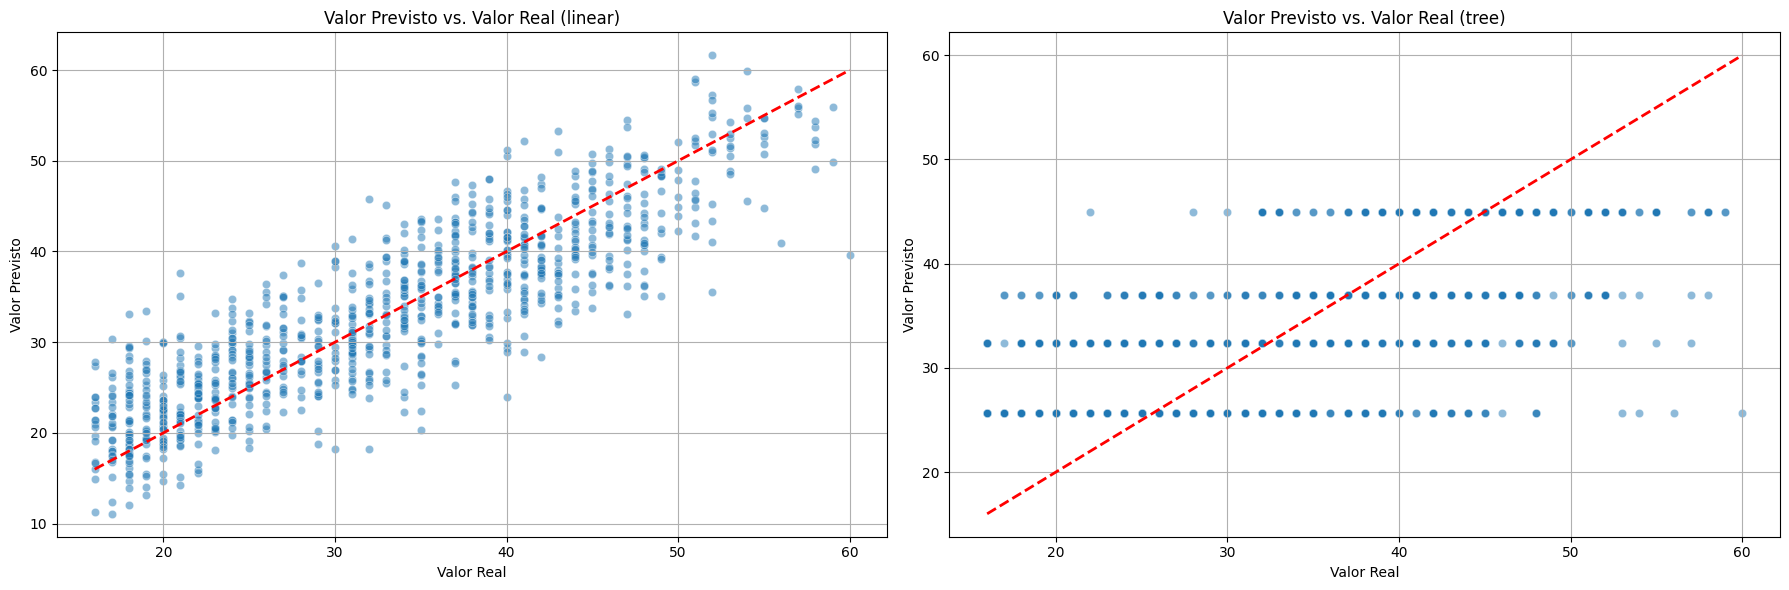

## **Gráfico do Valor Previsto vs Valor Real com EfficientNetB2 - Tree max_depth=3**

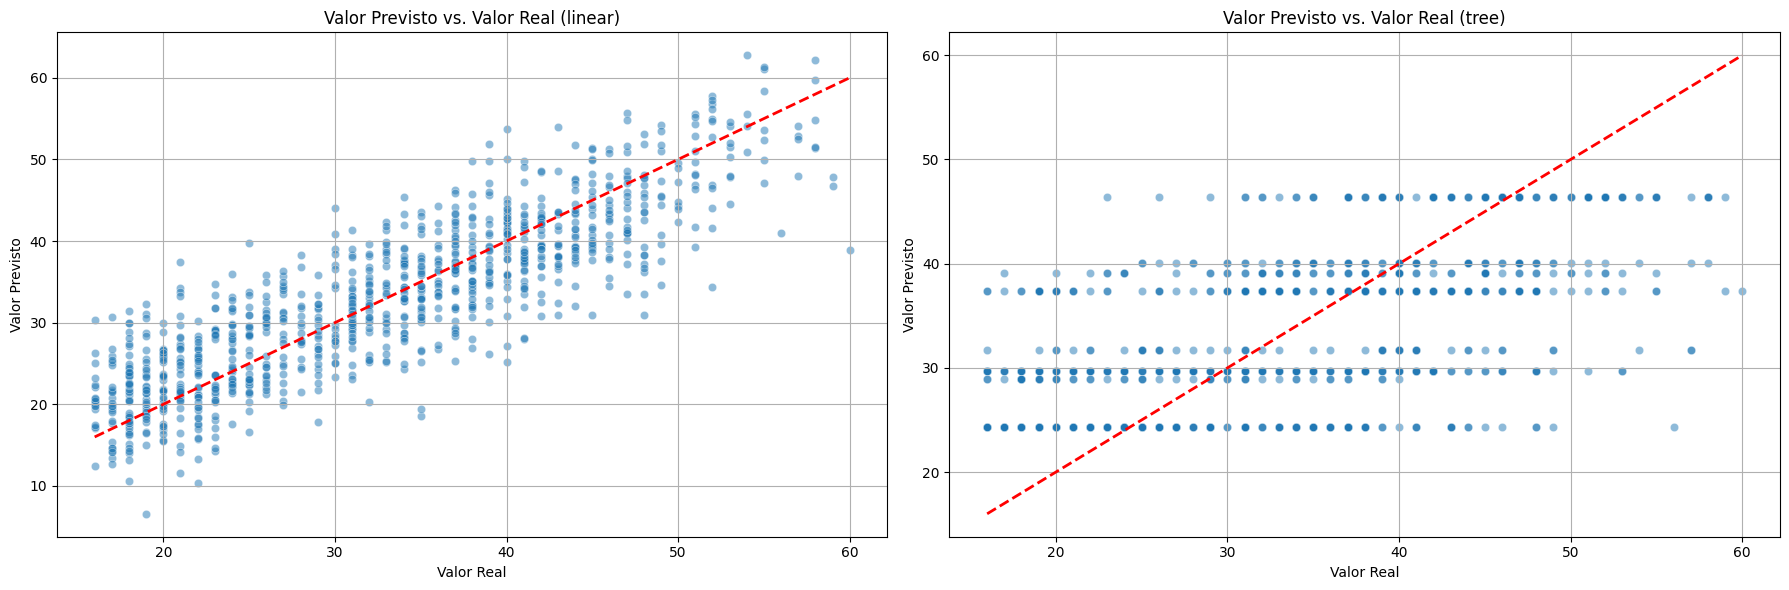

## **Gráfico do Valor Previsto vs Valor Real com EfficientNetB3 - Tree max_depth=5**

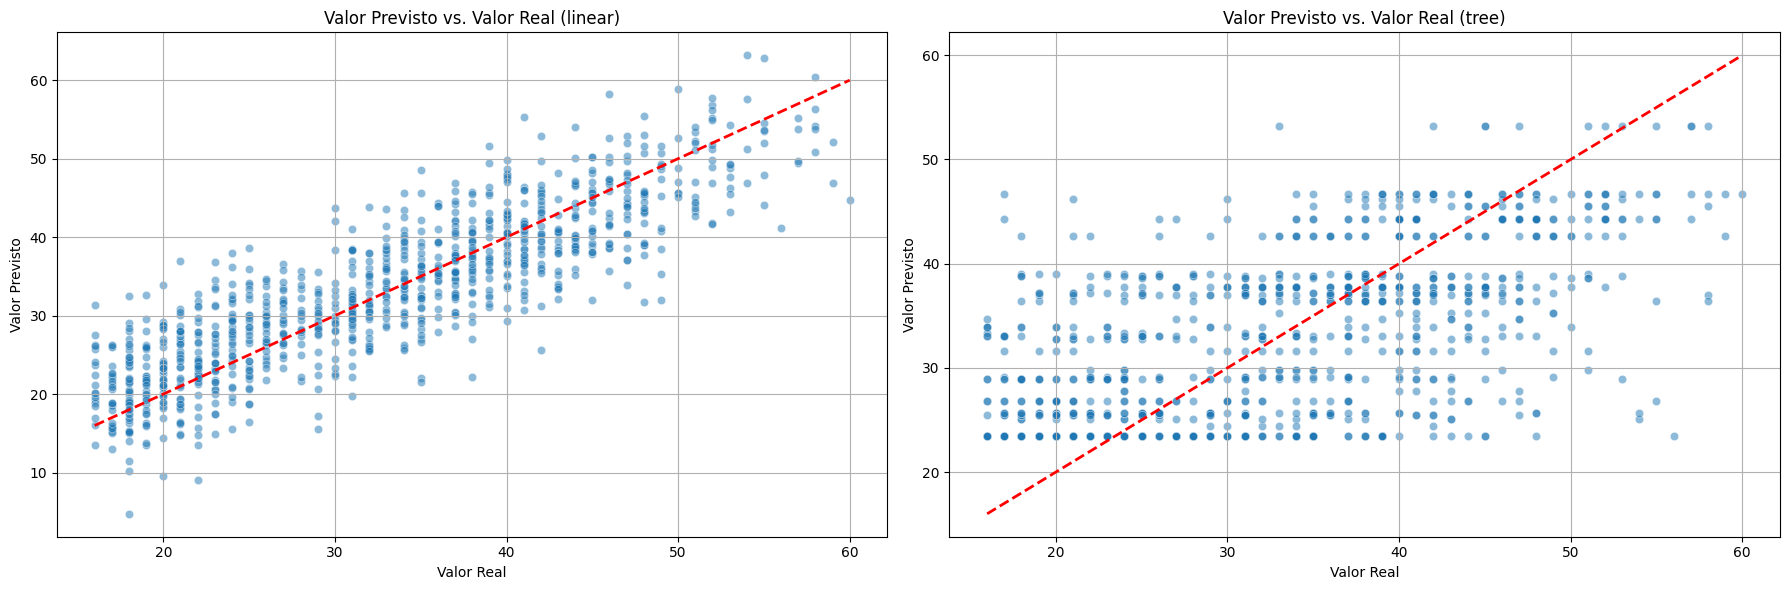

### **FIM**